# ResNet-18 + Attention MIL：可复现结果展示

本 Notebook 直接调用项目原始模型实现，完成一次可离线运行的 CPU 实验。
**所有图像与标签都是合成数据，以下结果不是患者数据实验，也不代表医学性能。**

运行方法：按照 `README.MD` 安装依赖，选择项目内核后 Restart Kernel and Run All。
演示冻结随机初始化的 ResNet-18 编码器，只训练注意力层和分类头，固定 6 轮。
原始 CUDA 训练入口和私有数据要求保留在项目中。

In [1]:
from pathlib import Path
import sys
import json
import platform
import importlib.metadata as metadata

ROOT = Path.cwd()
assert (ROOT / 'code' / 'reproduce_demo.py').is_file(), '请从项目根目录打开 Notebook'
sys.path.insert(0, str(ROOT / 'code'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from reproduce_demo import run_demo, synthetic_bags, SEED

print('Python:', platform.python_version())
for package in ['torch', 'torchvision', 'numpy', 'Pillow', 'scikit-learn', 'matplotlib']:
    print(f'{package}: {metadata.version(package)}')
print('Seed:', SEED, '| device: CPU | data: synthetic only')

Python: 3.11.9
torch: 2.5.1
torchvision: 0.20.1
numpy: 2.4.2
Pillow: 12.1.1
scikit-learn: 1.8.0
matplotlib: 3.10.8
Seed: 20260811 | device: CPU | data: synthetic only


## 1. 查看合成输入

每个样本袋包含两张 64×64 RGB 图像。类别由色块通道决定，叠加随机噪声。
训练、验证、测试分别使用不同种子生成；这只是检查模型和展示流程的简单任务。

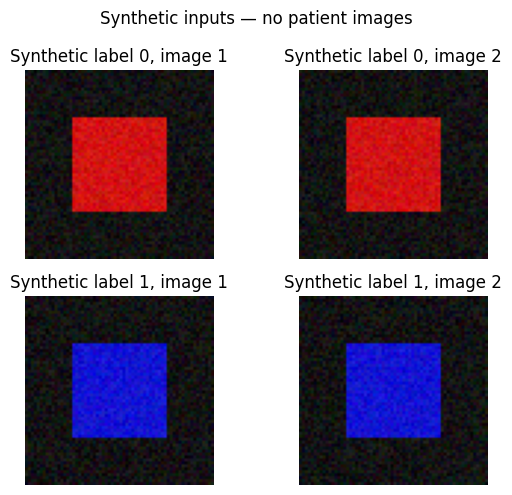

In [2]:
bags, labels = synthetic_bags(SEED + 1)
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
for row in range(2):
    for column in range(2):
        axes[row, column].imshow(bags[row][column].permute(1, 2, 0).numpy())
        axes[row, column].set_title(f'Synthetic label {labels[row]}, image {column + 1}')
        axes[row, column].axis('off')
fig.suptitle('Synthetic inputs — no patient images')
plt.tight_layout()
plt.show()

## 2. 执行实验并验证复现

下面实际执行两次实验，并逐项比较完整结果。相同环境下应完全一致。
两个运行只写入被 Git 忽略的 `outputs/`；已执行输出随 Notebook 一并保存。

In [3]:
result = run_demo(ROOT / 'outputs' / 'demo')
repeat = run_demo(ROOT / 'outputs' / 'repeat')
assert result == repeat, '两次执行输出不一致，请检查依赖或计算环境'
print('PASS: 两次 CPU 运行的完整 JSON 结果一致')
print('Data source:', result['data_source'])
print('Epochs:', result['epochs'])
print('Validation-selected threshold:', round(result['validation']['threshold'], 6))

PASS: 两次 CPU 运行的完整 JSON 结果一致
Data source: synthetic_only_not_clinical_results
Epochs: 6
Validation-selected threshold: 0.546077


## 3. 损失与概率

阈值仅由验证集确定，随后用于测试集。这里固定训练轮数，没有通过测试集挑选模型。
图表是程序本次计算出的数值；简单合成数据上的高分没有临床解释。

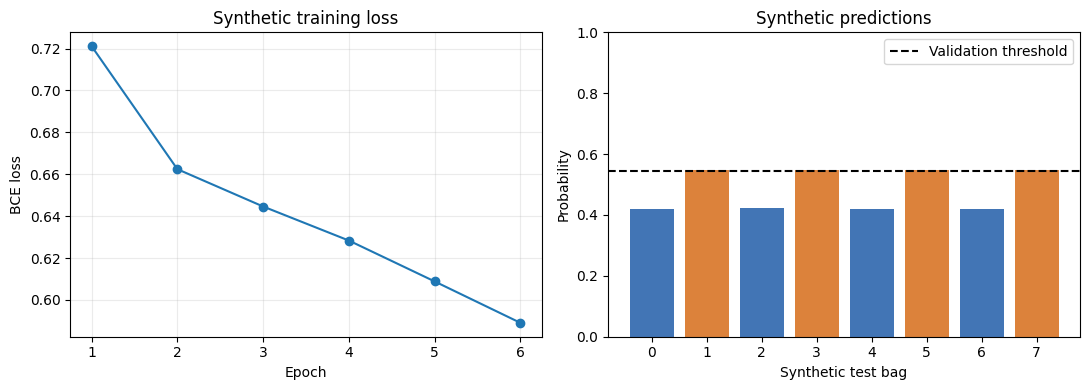

In [4]:
history = result['history']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([r['epoch'] for r in history], [r['train_loss'] for r in history], 'o-')
axes[0].set(xlabel='Epoch', ylabel='BCE loss', title='Synthetic training loss')
axes[0].grid(alpha=0.25)
indices = np.arange(len(result['test_labels']))
colors = ['#4275b5' if label == 0 else '#dc823b' for label in result['test_labels']]
axes[1].bar(indices, result['test_probabilities'], color=colors)
axes[1].axhline(result['validation']['threshold'], linestyle='--', color='black', label='Validation threshold')
axes[1].set(xlabel='Synthetic test bag', ylabel='Probability', ylim=(0, 1), title='Synthetic predictions')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. 指标、混淆矩阵与注意力

原始代码的 `pr_auc` 字段使用 `average_precision_score`，即 AP，而不是梯形积分 PR 曲线面积。
注意力权重在每个袋内加起来为 1；它是模型聚合权重，并不能证明医学因果关系。

| Metric | Validation (synthetic) | Test (synthetic) |
|---|---:|---:|
| n | 8.000000 | 8.000000 |
| roc_auc | 1.000000 | 1.000000 |
| pr_auc | 1.000000 | 1.000000 |
| accuracy | 1.000000 | 1.000000 |
| sensitivity | 1.000000 | 1.000000 |
| specificity | 1.000000 | 1.000000 |
| brier | 0.190343 | 0.190295 |

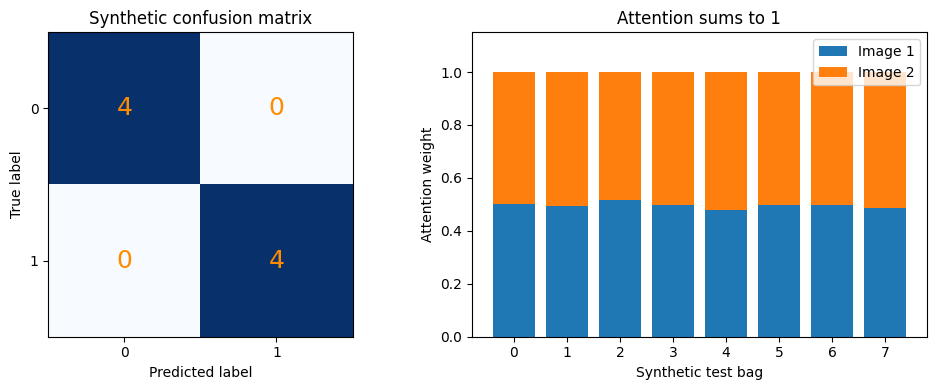

In [5]:
metric_names = ['n', 'roc_auc', 'pr_auc', 'accuracy', 'sensitivity', 'specificity', 'brier']
rows = ['| Metric | Validation (synthetic) | Test (synthetic) |', '|---|---:|---:|']
for name in metric_names:
    rows.append(f"| {name} | {result['validation'][name]:.6f} | {result['test'][name]:.6f} |")
display(Markdown('\n'.join(rows)))
m = result['test']
matrix = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(matrix, cmap='Blues', vmin=0, vmax=max(1, matrix.max()))
for row in range(2):
    for column in range(2):
        axes[0].text(column, row, str(matrix[row, column]), ha='center', va='center', color='darkorange', fontsize=18)
axes[0].set(xticks=[0, 1], yticks=[0, 1], xlabel='Predicted label', ylabel='True label', title='Synthetic confusion matrix')
attention = np.array(result['test_attention'])
assert np.allclose(attention.sum(axis=1), 1.0)
axes[1].bar(indices, attention[:, 0], label='Image 1')
axes[1].bar(indices, attention[:, 1], bottom=attention[:, 0], label='Image 2')
axes[1].set(xlabel='Synthetic test bag', ylabel='Attention weight', ylim=(0, 1.15), title='Attention sums to 1')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. 版本与使用范围

- 提交版本标签：`v1.0.0`；README 提供安装、运行、Git 管理及真实训练步骤。
- `code/train_resnet_mil.py` 为原始实现；本演示调用其中模型、种子与指标函数。
- 完整真实训练还需要相同的私有数据、划分清单、预训练权重和 CUDA 环境。
- 该 Notebook 验证公开演示可复现；它不意味着已经复现真实数据实验。
- Notebook 中没有私有图像、患者逐例信息或真实预测记录。